In [10]:
#!/usr/bin/env python
# coding: utf-8

#import
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import glob
import matplotlib.pyplot as plt
import fiona
import rasterio.mask
from datetime import datetime
from rasterio.warp import reproject, Resampling


In [3]:
# set directory and task 1, which will influence output directory 
dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/"
Task_number = 1

In [4]:
#prepare LiDAR data
lidar = glob.glob(os.path.join(dir, "lidar","*SNEX*"))

# Split by underscore and pick the part that looks like a date
parts = os.path.basename(lidar[0]).split("_")
for part in parts:
    if part.isdigit() and len(part) == 8:
        date_str = part
        break

date_obj = datetime.strptime(date_str, "%Y%m%d")
outfile = os.path.join(dir, "lidar", "lidar_"+date_str+".tif")

if os.path.exists(outfile):
    print(f"Skipping existing LiDAR raster: {outfile}")
    lidar_raster = outfile
else:
    with rasterio.open(lidar[0]) as src:
        data = src.read(1, masked=True)
        profile = src.profile
        profile.update(dtype=rasterio.float32, nodata=-9999)
        outfile = os.path.join(dir, "lidar", "lidar_"+date_str+".tif")
    #Replace NaNs with -9999
    data_filled = np.where(np.isnan(data), -9999, data)

    # Write the new raster
    with rasterio.open(outfile, "w", **profile) as dst:
        dst.write(data_filled.astype("float32"), 1)
        
    lidar_raster = outfile


Skipping existing LiDAR raster: C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/lidar\lidar_20230405.tif


In [5]:
#Convert HMS from inches to meters
if Task_number == 1:
    modeled = os.path.join(dir, "modeled/Task1")
else:
    modeled = os.path.join(dir, "modeled/Task2")


HMS_EB = glob.glob(os.path.join(modeled, "*EB_snow_depth*.tif"))[0]
HMS_TI = glob.glob(os.path.join(modeled, "*TI_snow_depth*.tif"))[0]

out_path = os.path.join(modeled, "HMS_EB_inches.tif")
if os.path.exists(out_path):
    print(f"Skipping existing LiDAR raster: {outfile}")
else:
    with rasterio.open(HMS_EB) as src:
        raster_data = src.read(1, masked=True).filled(np.nan)
        out_raster = raster_data * 0.0254
        
        # Replace NaN with NoData value
        nodata_val = -9999
        out_raster = np.where(np.isnan(out_raster), nodata_val, out_raster)
        
        profile = src.profile
        profile.update(dtype=rasterio.float32, nodata=nodata_val)
        
        with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)


out_path = os.path.join(modeled, "HMS_TI_inches.tif")
if os.path.exists(out_path):
    print(f"Skipping existing LiDAR raster: {outfile}")
else:
    with rasterio.open(HMS_TI) as src:
        raster_data = src.read(1, masked=True).filled(np.nan)
        out_raster = raster_data * 0.0254
        
        # Replace NaN with NoData value
        nodata_val = -9999
        out_raster = np.where(np.isnan(out_raster), nodata_val, out_raster)
        
        profile = src.profile
        profile.update(dtype=rasterio.float32, nodata=nodata_val)
        
        with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)


Skipping existing LiDAR raster: C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/lidar\lidar_20230405.tif
Skipping existing LiDAR raster: C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/lidar\lidar_20230405.tif


In [ ]:
rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
}


In [ ]:
MCS = os.path.join(dir, "MCS_outline/basin_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]


if Task_number == 1:
    out_dir = os.path.join(dir, "outputs/task1/")
else:
    out_dir = os.path.join(dir, "outputs/task2/")

rasters_dir = os.path.join(out_dir, "rasters/")
figs_dir = os.path.join(out_dir, "figs/")

stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    out_name = f"{model}_basin_clip.tif"
    out_path = os.path.join(rasters_dir, out_name)

    if os.path.exists(out_path):
        print(f"Skipping existing LiDAR raster: {out_name}")
    else:
        for raster in raster_list:
            with rasterio.open(raster) as src:
                out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
                profile = src.profile

            with rasterio.open(out_path, "w", **profile) as dest:
                dest.write(out_image)

# Compute statistics
        data = out_image  # 1 band raster, extract 2D array
        mask = (data == -9999)
        data_masked = np.ma.array(data, mask=mask)  # mask nodata

        raster_stats = {
            "file": out_name,
            "model": model,
            "min": data_masked.min(),
            "mean": data_masked.mean(),
            "max": data_masked.max(),
            "zeros": np.sum(data_masked == 0)
        }
        
        stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(figs_dir, "basin_stats.csv")
stats_df.to_csv(stats_csv, index=False)

In [8]:
rasters = {
    "HMS Energy Balance": glob.glob(os.path.join(rasters_dir, "*HMS_EB_basin_clip*.tif")),
    "HMS Temperature Index": glob.glob(os.path.join(rasters_dir, "*HMS_TI_basin_clip*.tif")),
    "iSnobal": glob.glob(os.path.join(rasters_dir, "*iSnobal_basin_clip*.tif")),
    "SnowModel": glob.glob(os.path.join(rasters_dir, "*SnowModel_basin_clip*.tif")),
}


In [18]:
for i, (model, raster_list) in enumerate(rasters.items()):
    raster_path = raster_list[0] 
    
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)
        print(model)
        print(src.crs)

HMS Energy Balance
EPSG:32611
HMS Temperature Index
EPSG:32611
iSnobal
EPSG:32611
SnowModel
None


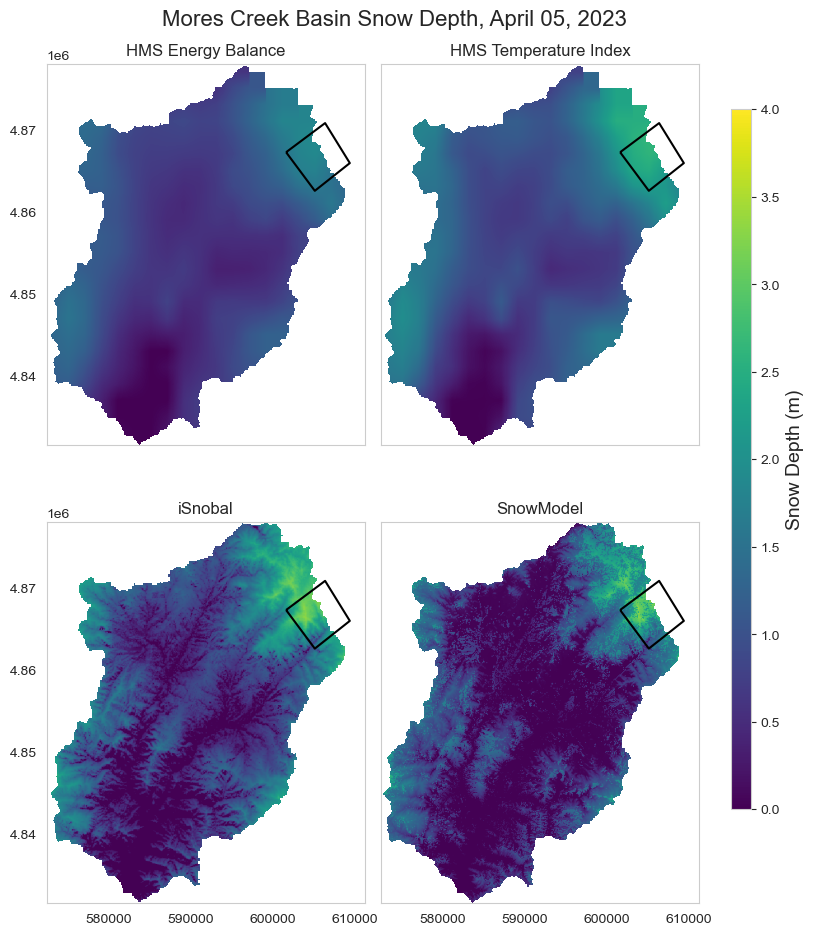

In [30]:
lidar_shp = gpd.read_file(os.path.join(dir, "MCS_outline/MCS_outline.shp"))

fig, axes = plt.subplots(2, 2, figsize=(8, 10), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster_list) in enumerate(rasters.items()):
    raster_path = raster_list[0] 
    
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        #extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].grid(False)
    lidar_shp.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1.5)


# Add colorbar

#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, extend="max", label="Snow Depth")

# --- 5. Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space

# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

fig.suptitle(f"Mores Creek Basin Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.savefig(os.path.join(figs_dir, "Basin_models.png"), dpi=300, bbox_inches="tight")

plt.show()


{'HMS_EB': ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/modeled/Task1\\HMS_EB_inches.tif'], 'HMS_TI': ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/modeled/Task1\\HMS_TI_inches.tif'], 'iSnobal': ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/modeled/Task1\\thickness_2023-04-05T23_00_00.tif'], 'SnowModel': ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/modeled/Task1\\snod_746_04-05-2023_12.tif']}
Skipping existing LiDAR raster: HMS_EB_basin_clip.tif
Skipping existing LiDAR raster: HMS_TI_basin_clip.tif
Skipping existing LiDAR raster: iSnobal_basin_clip.tif
Skipping existing LiDAR raster: SnowModel_basin_clip.tif
HMS Energy Balance 1 ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/outputs/task1/rasters\\HMS_EB_basin_clip.tif']
HMS Temperature Index 1 ['C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/outputs/task1/rasters\\HMS_TI_

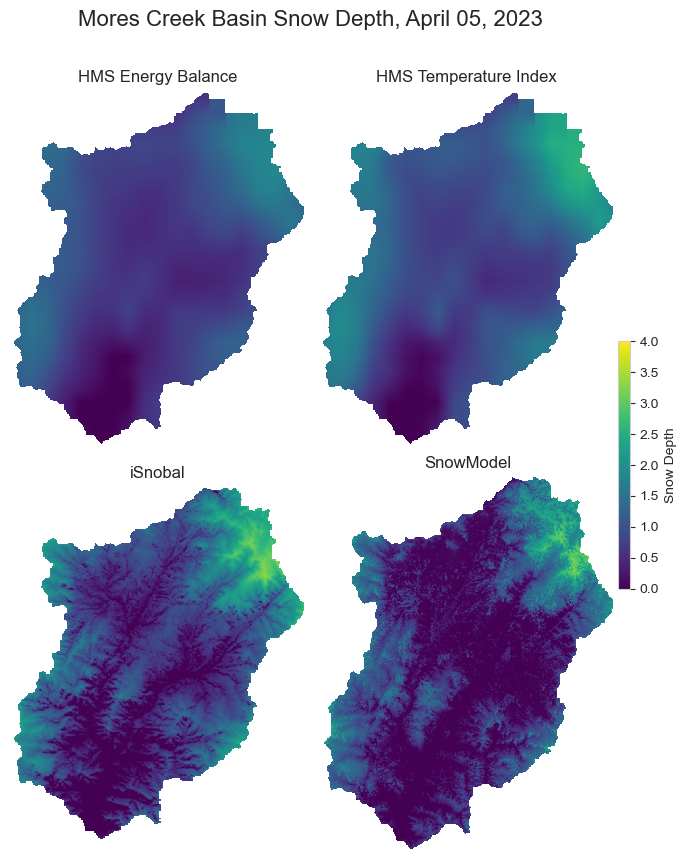

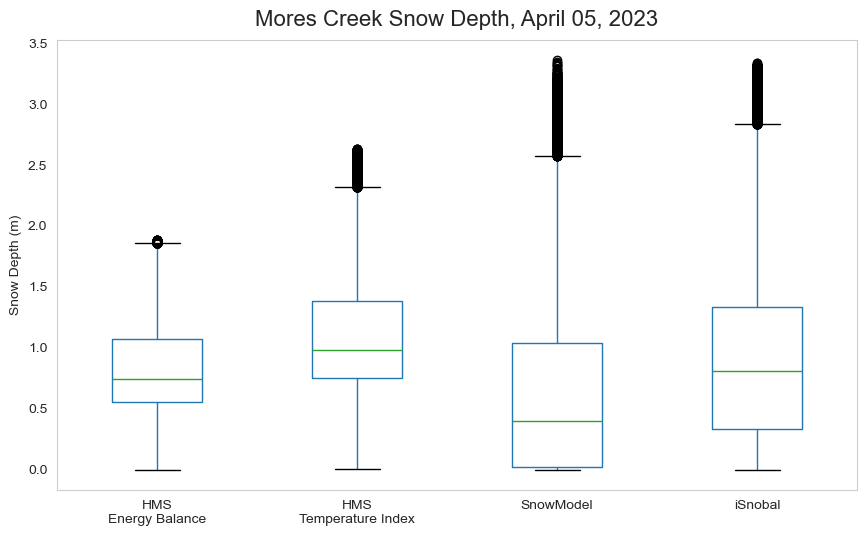

skipping creation of out_name
skipping creation of out_name
skipping creation of out_name
skipping creation of out_name
skipping creation of out_name


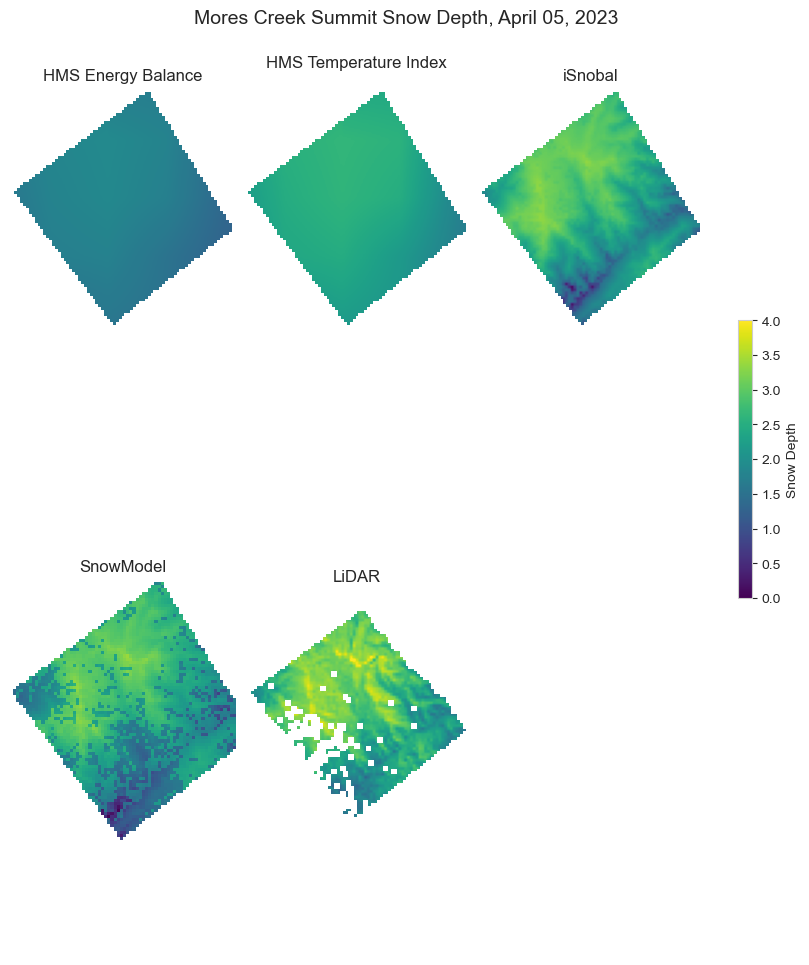

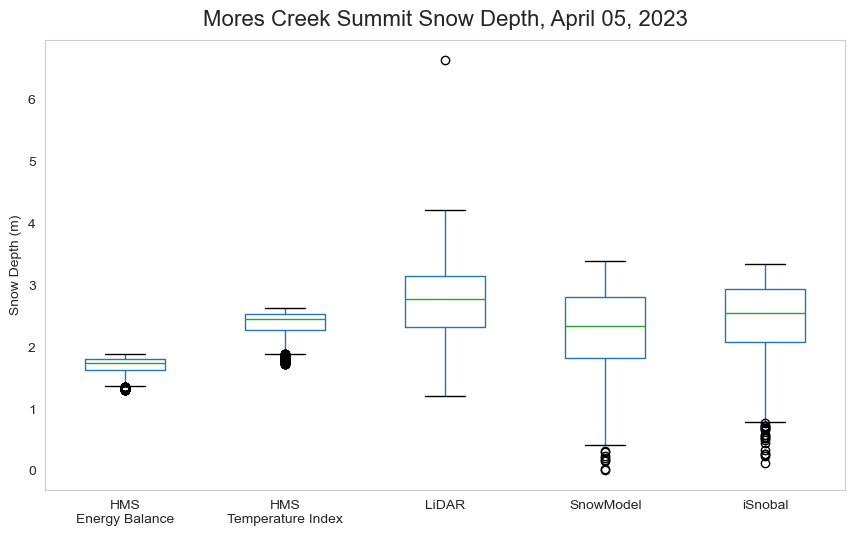

Assigned CRS EPSG:32611 to SnowModel because it was missing.


In [6]:

dfs = []

for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)




fig, ax = plt.subplots(figsize=(10, 6))

# Suppose your DataFrame has a column "Model" with long names
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove pandas' default title
ax.set_title("")

# Create multi-line labels by inserting '\n'
labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = []
for lbl in labels:
    if len(lbl) > 12:  # arbitrarily split long labels
        # split in half
        mid = len(lbl) // 2
        # find nearest space to split
        space_idx = lbl.rfind(" ", 0, mid)
        if space_idx == -1:
            space_idx = mid
        lbl = lbl[:space_idx] + "\n" + lbl[space_idx:].strip()
    new_labels.append(lbl)

ax.set_xticklabels(new_labels)

# Figure-level title
fig.suptitle(f"Mores Creek Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)

ax.set_ylabel("Snow Depth (m)")
ax.set_xlabel("")

#plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(figs_dir, "basin_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()



MCS = os.path.join(dir, "MCS_outline/MCS_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
    "LiDAR": [lidar_raster]
}



stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    for raster in raster_list:
        out_name = f"{model}_MCS_clip.tif"
        out_path = os.path.join(rasters_dir, out_name)
        
        if os.path.exists(out_path):
            print(f"skipping creation of out_name")
            
        else:
            with rasterio.open(raster) as src:
                out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
                out_meta = src.meta.copy()

            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
            })

            # Include model in output filename
            out_name = f"{model}_MCS_clip.tif"
            out_path = os.path.join(rasters_dir, out_name)

            with rasterio.open(out_path, "w", **out_meta) as dest:
                dest.write(out_image)

    # Compute statistics
            data = out_image[0]  # 1 band raster, extract 2D array
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata

            raster_stats = {
                "file": out_name,
                "model": model,
                "min": data_masked.min(),
                "mean": data_masked.mean(),
                "max": data_masked.max(),
                "zeros": np.sum(data_masked == 0)
            }
            
            stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(figs_dir, "MCS_stats.csv")
stats_df.to_csv(stats_csv, index=False)



rasters = {
    "HMS Energy Balance": os.path.join(rasters_dir, "HMS_EB_MCS_clip.tif"),
    "HMS Temperature Index": os.path.join(rasters_dir, "HMS_TI_MCS_clip.tif"),
    "iSnobal": os.path.join(rasters_dir, "iSnobal_MCS_clip.tif"),
    "SnowModel": os.path.join(rasters_dir, "SnowModel_MCS_clip.tif"),
    "LiDAR": os.path.join(rasters_dir, "LiDAR_MCS_clip.tif")
}


fig, axes = plt.subplots(2, 3, figsize=(8, 10),constrained_layout=True)
axes = axes.flatten()  # flatten to 1D array for easy looping


axes = axes.flatten()

for i, (model, raster_path) in enumerate(rasters.items()):
    #raster_path = raster_list[0] 
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0) #aspect="auto")
    axes[i].set_title(model)
    axes[i].axis("off")

axes[-1].axis("off")
# Add colorbar
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, label="Snow Depth")
fig.suptitle(f"Mores Creek Summit Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=14,  y=0.95)

# fig.subplots_adjust(
#     #wspace=.01,
#     hspace=0.01,
#     right=0.85
#     #top=0.90
# )

plt.savefig(os.path.join(figs_dir, "MCS_models.png"), dpi=300, bbox_inches="tight")

plt.show()




dfs = []

for model, raster in rasters.items():
    #for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)



fig, ax = plt.subplots(figsize=(10, 6))

# Suppose your DataFrame has a column "Model" with long names
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove pandas' default title
ax.set_title("")

# Create multi-line labels by inserting '\n'
labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = []
for lbl in labels:
    if len(lbl) > 12:  # arbitrarily split long labels
        # split in half
        mid = len(lbl) // 2
        # find nearest space to split
        space_idx = lbl.rfind(" ", 0, mid)
        if space_idx == -1:
            space_idx = mid
        lbl = lbl[:space_idx] + "\n" + lbl[space_idx:].strip()
    new_labels.append(lbl)

ax.set_xticklabels(new_labels)

# Figure-level title
fig.suptitle(f"Mores Creek Summit Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)

ax.set_ylabel("Snow Depth (m)")
ax.set_xlabel("")

#plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(figs_dir, "MCS_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()



del rasters["LiDAR"]
lidar = os.path.join(rasters_dir, "LiDAR_MCS_clip.tif")


with rasterio.open(lidar) as src:
    lidar_data = src.read(1, masked=True)
    profile = src.profile                 # for writing outputs
    lidar_crs = src.crs
    lidar_transform = src.transform  # True where LiDAR is masked


for model, raster_path in rasters.items():
    with rasterio.open(raster_path) as src:
        model_data = src.read(1, masked=True)
        model_transform = src.transform
        model_crs = src.crs

        # Assign CRS if missing
        if model_crs is None:
            model_crs = lidar_crs
            print(f"Assigned CRS {model_crs} to {model} because it was missing.")

        # Prepare array for reprojected data
        reprojected_model = np.empty(lidar_data.shape, dtype=np.float32)

        # Reproject/resample model to match LiDAR
        reproject(
            source=model_data,
            destination=reprojected_model,
            src_transform=model_transform,
            src_crs=model_crs,
            dst_transform=lidar_transform,
            dst_crs=lidar_crs,
            resampling=Resampling.bilinear
        )

        # Mask wherever either raster is NaN / masked
        combined_mask = (lidar_data.data == -9999) | (reprojected_model == -9999)
        model_masked = np.ma.array(reprojected_model, mask=combined_mask)
        lidar_masked = np.ma.array(lidar_data, mask=combined_mask)

        # Compute difference
        diff_data = lidar_masked - model_masked

        # Write difference raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, compress="lzw", nodata = -9999)

        # Write difference raster
        out_path_diff = os.path.join(rasters_dir, f"{model.replace(' ', '_')}_lidar_diff.tif")
        out_path_resample = os.path.join(rasters_dir, f"{model.replace(' ', '_')}_lidar_resample.tif")
        
        with rasterio.open(out_path_resample, "w", **out_profile) as dst:
            dst.write(model_masked.filled(np.nan).astype(np.float32), 1)
        with rasterio.open(out_path_diff, "w", **out_profile) as dst:
            dst.write(diff_data.filled(np.nan).astype(np.float32), 1)





